# Base Model: Firm Dynamics and Misallocation from Policy Distortions

**Hopenhayn (1992) industry-equilibrium model with idiosyncratic distortions (Restuccia & Rogerson, 2008)**

This notebook solves three economies and compares aggregate output:
1. **Efficient**: No distortions (benchmark)
2. **Untargeted distortion**: Misallocation uncorrelated with productivity
3. **Mistargeted subsidy**: Misallocation against productive firms

Because aggregate labor input is fixed across scenarios, output differences measure the pure **TFP cost of misallocation**.

## Setup & Imports

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Add src to path (go up one directory from notebooks/)
sys.path.insert(0, '../src')

from ge_model import (
    run_base_scenario,
    CALIBRATION,
    s_grid,
    plot_base_output_loss,
    plot_base_employment_reallocation,
)

print("[OK] Imports successful")
print(f"[OK] Working directory: {os.getcwd()}")

[OK] Imports successful
[OK] Working directory: c:\Users\wb611463\OneDrive - WBG\Desktop\GE Modelling\notebooks


## 2. Calibration Parameters

In [3]:
# Display calibration as a readable table
calib_display = {
    'Parameter': [
        'Productivity grid points',
        'AR(1) persistence (ρ)',
        'Innovation std dev (σ)',
        'Labor share (α)',
        'Discount factor (β)',
        'Fixed operating cost',
        'Entry cost',
        'Aggregate labor supply',
    ],
    'Value': [
        CALIBRATION['N_Z'],
        CALIBRATION['RHO'],
        CALIBRATION['SIGMA'],
        CALIBRATION['ALPHA'],
        CALIBRATION['BETA'],
        f"{CALIBRATION['CF']:.2f}",
        f"{CALIBRATION['CE']:.2f}",
        CALIBRATION['L_SUPPLY'],
    ]
}
calib_df = pd.DataFrame(calib_display)
print("Base Model Calibration (stylized, illustrative):")
print(calib_df.to_string(index=False))
print(f"\nDistortion wedges (τ): {CALIBRATION['TAU_VALS']}")
print("  τ < 0: subsidy  |  τ = 0: no distortion  |  τ > 0: tax")

Base Model Calibration (stylized, illustrative):
               Parameter Value
Productivity grid points    25
   AR(1) persistence (ρ)   0.9
  Innovation std dev (σ)   0.2
         Labor share (α)  0.65
     Discount factor (β)  0.85
    Fixed operating cost  0.55
              Entry cost  1.10
  Aggregate labor supply   1.0

Distortion wedges (τ): [-0.3  -0.15  0.    0.15  0.3 ]
  τ < 0: subsidy  |  τ = 0: no distortion  |  τ > 0: tax


## 3. Discretization: AR(1) Productivity Process

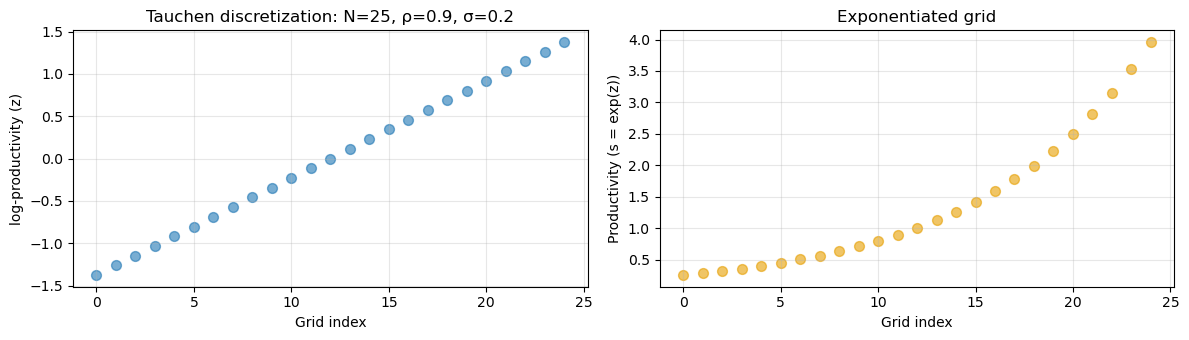

Log-productivity range: [-1.376, 1.376]
Productivity range: [0.252, 3.961]


In [4]:
from ge_model import tauchen

# Discretize the AR(1)
z_grid, Q = tauchen(CALIBRATION['N_Z'], CALIBRATION['RHO'], CALIBRATION['SIGMA'])

# Productivity grid: s = exp(z)
s_grid_local = np.exp(z_grid)

# Plot the discretized process
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

# Left: log-productivity grid
ax1.scatter(range(len(z_grid)), z_grid, alpha=0.6, s=50)
ax1.set_xlabel('Grid index')
ax1.set_ylabel('log-productivity (z)')
ax1.set_title(f'Tauchen discretization: N={CALIBRATION["N_Z"]}, ρ={CALIBRATION["RHO"]}, σ={CALIBRATION["SIGMA"]}')
ax1.grid(alpha=0.3)

# Right: productivity grid (s = exp(z))
ax2.scatter(range(len(s_grid_local)), s_grid_local, alpha=0.6, s=50, color='#E69F00')
ax2.set_xlabel('Grid index')
ax2.set_ylabel('Productivity (s = exp(z))')
ax2.set_title('Exponentiated grid')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Log-productivity range: [{z_grid[0]:.3f}, {z_grid[-1]:.3f}]")
print(f"Productivity range: [{s_grid_local[0]:.3f}, {s_grid_local[-1]:.3f}]")

## 4. Model Specification

In [5]:
model_spec = """
FIRM PROBLEM (per-period static choice):
  max_n  (1 - τ) · p · s · n^α - w·n
  
  where:
    • n = labor
    • s = idiosyncratic productivity (persistent, AR(1) in logs)
    • τ = time-invariant distortion wedge (assigned at entry)
    • p = equilibrium output price
    • α = labor share (0.65, returns to labor = 65%)
    • w = wage (normalized to 1.0)
  
  First-order condition: n(s) = [((1-τ)·p·s·α)/w]^(1/(1-α))

VALUE FUNCTION (dynamic, with endogenous exit):
  V(s) = π(s) - cf + β·E[max(V(s'), 0)]
  
  where:
    • π(s) = ((1-τ)·p·s - w·n(s)) = static profit
    • cf = 0.55 = fixed operating cost
    • β = 0.85 = discount factor
    • Exit rule: firm exits if V(s) < 0

EQUILIBRIUM CONDITIONS:
  1. Free entry: E_ν[V(s)] = ce  (expected value at entry = entry cost)
  2. Labor-market clearing: M·L = L_supply  (exogenous labor supply = 1.0)
  
  Solution method:
    • Discretize s via Tauchen (N=25 points)
    • Solve V(s) for each distortion type via VFI
    • Find equilibrium price p* that satisfies free entry (Brentq root-finding)
    • Scale to clear labor market
"""

print(model_spec)


FIRM PROBLEM (per-period static choice):
  max_n  (1 - τ) · p · s · n^α - w·n
  
  where:
    • n = labor
    • s = idiosyncratic productivity (persistent, AR(1) in logs)
    • τ = time-invariant distortion wedge (assigned at entry)
    • p = equilibrium output price
    • α = labor share (0.65, returns to labor = 65%)
    • w = wage (normalized to 1.0)
  
  First-order condition: n(s) = [((1-τ)·p·s·α)/w]^(1/(1-α))

VALUE FUNCTION (dynamic, with endogenous exit):
  V(s) = π(s) - cf + β·E[max(V(s'), 0)]
  
  where:
    • π(s) = ((1-τ)·p·s - w·n(s)) = static profit
    • cf = 0.55 = fixed operating cost
    • β = 0.85 = discount factor
    • Exit rule: firm exits if V(s) < 0

EQUILIBRIUM CONDITIONS:
  1. Free entry: E_ν[V(s)] = ce  (expected value at entry = entry cost)
  2. Labor-market clearing: M·L = L_supply  (exogenous labor supply = 1.0)
  
  Solution method:
    • Discretize s via Tauchen (N=25 points)
    • Solve V(s) for each distortion type via VFI
    • Find equilibrium price

## 5. Solve Three Regimes

In [6]:
# Run all three regimes
regimes = ["efficient", "untargeted", "mistargeted"]
results = {}

for regime in regimes:
    print(f"Solving {regime}...", end=" ")
    res = run_base_scenario(regime)
    results[regime] = res
    print(f"✓ p*={res['p']:.4f}, Y={res['aggregate_output']:.4f}")

print("\n✓ All regimes solved.")

Solving efficient... ✓ p*=1.2897, Y=1.1929
Solving untargeted... ✓ p*=1.2126, Y=1.0565
Solving mistargeted... ✓ p*=1.6424, Y=0.8262

✓ All regimes solved.


## 6. Results Table

In [7]:
# Build results table
rows = []
baseline_Y = results["efficient"]["aggregate_output"]

for regime in regimes:
    res = results[regime]
    rows.append({
        "Regime": regime.capitalize(),
        "Eq. Price (p*)": res["p"],
        "Aggregate Output": res["aggregate_output"],
        "Output (% of efficient)": 100 * res["aggregate_output"] / baseline_Y,
        "Output Loss (%)": 100 * (1 - res["aggregate_output"] / baseline_Y),
        "Firm Mass": res["aggregate_mass_firms"],
        "Exit Rate": res["exit_rate"],
    })

table = pd.DataFrame(rows)
print("\nEQUILIBRIUM RESULTS:")
print(table.to_string(index=False))

# Save to CSV (go up one directory)
os.makedirs('../results/base', exist_ok=True)
table.to_csv('../results/base/results_table.csv', index=False, float_format='%.4f')
print("\n[OK] Saved: ../results/base/results_table.csv")


EQUILIBRIUM RESULTS:
     Regime  Eq. Price (p*)  Aggregate Output  Output (% of efficient)  Output Loss (%)  Firm Mass  Exit Rate
  Efficient        1.289727          1.192859               100.000000         0.000000   0.419154   0.147769
 Untargeted        1.212568          1.056492                88.568034        11.431966   0.352381   0.121410
Mistargeted        1.642413          0.826159                69.258709        30.741291   0.233745   0.029830

[OK] Saved: ../results/base/results_table.csv


## 7. Visualizations

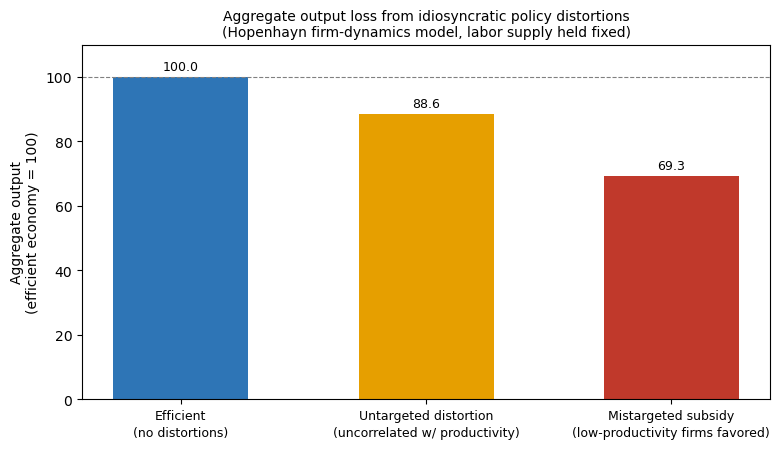

[OK] Saved: ../results/base/output_loss.png


In [8]:
# Chart 1: Output Loss
labels = {
    "efficient": "Efficient\n(no distortions)",
    "untargeted": "Untargeted distortion\n(uncorrelated w/ productivity)",
    "mistargeted": "Mistargeted subsidy\n(low-productivity firms favored)",
}

fig, ax = plot_base_output_loss(results, regimes, labels, save_path='../results/base/output_loss.png')
plt.show()
print("[OK] Saved: ../results/base/output_loss.png")

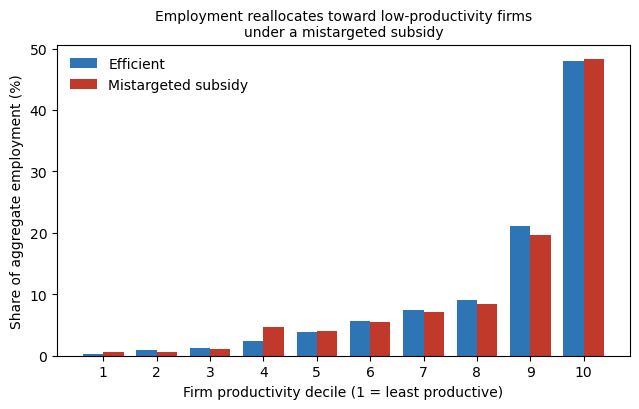

[OK] Saved: ../results/base/employment_reallocation.png


In [9]:
# Chart 2: Employment Reallocation
fig, ax = plot_base_employment_reallocation(results, s_grid, save_path='../results/base/employment_reallocation.png')
plt.show()
print("[OK] Saved: ../results/base/employment_reallocation.png")